In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score,f1_score
from tqdm.notebook import tqdm
import os
import anndata as ad
import matplotlib.pyplot as plt

In [4]:
from sklearn.ensemble import RandomForestClassifier
param_grid = {
    "max_depth":         [5, 10, 20, None],
    "max_features":      ["sqrt", "log2", 0.1, 0.25, 0.5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 5, 10],
    "bootstrap":         [True]
}

def random_forest_classifier(
      adata,
      y_col='geo_region_of_origin',
      n_estimators=500,
      max_depth=None,
      max_features='sqrt',
      min_samples_split=2,
      min_samples_leaf=1,
      bootstrap=True,
      label='90/10',
      random_state=0,
  ):
    # encode classes
    #uses pre-computed folds to calculate the data with adata.obsm[fold]
    # Here the
    classes = sorted(adata.obs[y_col].unique().tolist())
    class_dict = {c: i for i, c in enumerate(classes)}
    adata.obs['class_id'] = adata.obs[y_col].map(class_dict)


    # remove classes with too few samples
    fold_ids = sorted(list(adata.obsm.keys()))

    class_counts = adata.obs['class_id'].value_counts()
    keep_classes = class_counts[class_counts >= len(fold_ids)].index
    adata = adata[adata.obs['class_id'].isin(keep_classes)].copy()
    
    fold_ids = sorted(list(adata.obsm.keys()))
    adata.obs['fold_' + label] = None
    for i, fold in enumerate(fold_ids):
        fold_col = adata.obsm[fold][:, -1]
        test_mask = fold_col == 1
        train_mask = ~test_mask
        X_train = adata.obsm[fold][train_mask, :-1]
        X_test  = adata.obsm[fold][test_mask,  :-1]
        y_train = adata.obs.loc[train_mask, 'class_id'].to_numpy()

        clf = RandomForestClassifier(
              n_estimators=n_estimators,
              max_depth=max_depth,
              max_features=max_features,
              min_samples_split=min_samples_split,
              min_samples_leaf=min_samples_leaf,
              bootstrap=bootstrap,
              random_state=random_state,
              n_jobs=-1,
          )
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        adata.obs.loc[test_mask, 'pred'] = preds
        adata.obs.loc[test_mask, 'fold_' + label] = i

    return adata

In [3]:
n_tree_vals = [100]
split_files = sorted([f for f in os.listdir('../data/') if f.startswith('pcScores')])
f1s = np.zeros((len(split_files), len(n_tree_vals), 10))

for s, split_file in enumerate(split_files):
    adata = ad.read_h5ad(os.path.join('../data', split_file))
    split_no = split_file.split('.')[0][-2:]
    # Each PCA split has different folds
    for j, n_trees in tqdm(list(enumerate(n_tree_vals)), desc=split_file):
        result = random_forest_classifier(adata.copy(), n_estimators=n_trees, label=split_no)
        print(result)
        fold_col = 'fold_' + split_no
        folds = result.obs[fold_col].dropna().unique()
        for f, fold in enumerate(folds):
            sub = result[result.obs[fold_col] == fold].obs
            print(s, j, f)
            f1s[s, j, f] = f1_score(sub['class_id'].to_numpy(),
                                      sub['pred'].to_numpy(),
                                      average='macro')

pcScores_split_10.h5ad:   0%|          | 0/1 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 1107 × 2810
    obs: 'hgdp_id', 'population_id', 'population_name', 'country_of_origin', 'geo_region_of_origin', 'genotyping_id', 'sex', 'class_id', 'fold_10', 'pred'
    obsm: 'X_pca_fold_1', 'X_pca_fold_10', 'X_pca_fold_2', 'X_pca_fold_3', 'X_pca_fold_4', 'X_pca_fold_5', 'X_pca_fold_6', 'X_pca_fold_7', 'X_pca_fold_8', 'X_pca_fold_9'
0 0 0
0 0 1
0 0 2
0 0 3
0 0 4
0 0 5
0 0 6
0 0 7
0 0 8
0 0 9


pcScores_split_20.h5ad:   0%|          | 0/1 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 1107 × 2810
    obs: 'hgdp_id', 'population_id', 'population_name', 'country_of_origin', 'geo_region_of_origin', 'genotyping_id', 'sex', 'class_id', 'fold_20', 'pred'
    obsm: 'X_pca_fold_1', 'X_pca_fold_2', 'X_pca_fold_3', 'X_pca_fold_4', 'X_pca_fold_5'
1 0 0
1 0 1
1 0 2
1 0 3
1 0 4


pcScores_split_25.h5ad:   0%|          | 0/1 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 1107 × 2810
    obs: 'hgdp_id', 'population_id', 'population_name', 'country_of_origin', 'geo_region_of_origin', 'genotyping_id', 'sex', 'class_id', 'fold_25', 'pred'
    obsm: 'X_pca_fold_1', 'X_pca_fold_2', 'X_pca_fold_3', 'X_pca_fold_4'
2 0 0
2 0 1
2 0 2
2 0 3


pcScores_split_33.h5ad:   0%|          | 0/1 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 1107 × 2810
    obs: 'hgdp_id', 'population_id', 'population_name', 'country_of_origin', 'geo_region_of_origin', 'genotyping_id', 'sex', 'class_id', 'fold_33', 'pred'
    obsm: 'X_pca_fold_1', 'X_pca_fold_2', 'X_pca_fold_3'
3 0 0
3 0 1
3 0 2


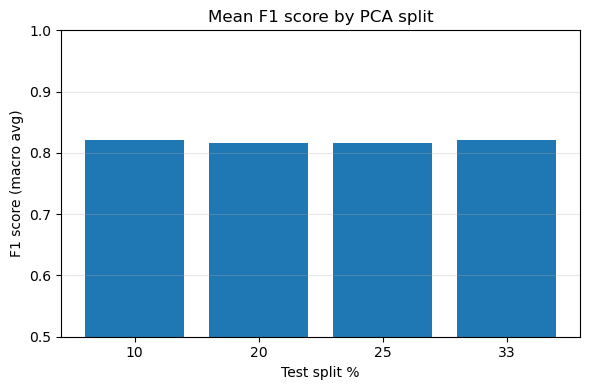

In [4]:
splits = ['10', '20', '25', '33']
n_folds_per_split = [10, 5, 4, 3]

mean_scores = []
for s, n_folds in enumerate(n_folds_per_split):
    fold_scores = [f1s[s, 0, f] for f in range(n_folds)]
    mean_scores.append(np.mean(fold_scores))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(splits, mean_scores)
ax.set_xlabel('Test split %')
ax.set_ylabel('F1 score (macro avg)')
ax.set_title('Mean F1 score by PCA split')
ax.set_ylim(.5, 1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [29]:
import numpy as np
from sklearn.metrics import confusion_matrix

def compute_macro_fpr_fnr(y_true, y_pred, n_classes):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))

    FP = cm.sum(axis=0) - np.diag(cm)
    FN = cm.sum(axis=1) - np.diag(cm)
    TP = np.diag(cm)
    TN = cm.sum() - (FP + FN + TP)

    fpr = FP / (FP + TN + 1e-12)
    fnr = FN / (FN + TP + 1e-12)

    return fpr.mean(), fnr.mean()

In [30]:
import anndata as ad
import pandas as pd
from itertools import product
from sklearn.metrics import f1_score

param_grid = {
    "max_depth": [5, 10, 20, None],
    "max_features": ["sqrt", "log2", 0.1, 0.25, 0.5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10],
    "bootstrap": [True]
}

adata = ad.read_h5ad('../data/pcScores_split_20.h5ad')

all_results = []

keys = list(param_grid.keys())
vals = list(param_grid.values())

for combin in product(*vals):
    params = dict(zip(keys, combin))

    result = random_forest_classifier(
        adata.copy(),
        n_estimators=100,
        max_depth=params['max_depth'],
        max_features=params['max_features'],
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        bootstrap=params['bootstrap'],
        label='20',
        random_state=0
    )

    fold_col = 'fold_20'
    folds = sorted(result.obs[fold_col].dropna().unique())

    fold_f1s = []
    fold_fprs = []
    fold_fnrs = []

    n_classes = result.obs['class_id'].nunique()

    for fold in folds:
        sub = result[result.obs[fold_col] == fold].obs
        y_true = sub['class_id'].to_numpy()
        y_pred = sub['pred'].to_numpy()

        fold_f1s.append(
            f1_score(y_true, y_pred, average='macro')
        )

        macro_fpr, macro_fnr = compute_macro_fpr_fnr(y_true, y_pred, n_classes)
        fold_fprs.append(macro_fpr)
        fold_fnrs.append(macro_fnr)

    all_results.append({
        'max_features': params['max_features'],
        'max_depth': params['max_depth'],
        'min_samples_split': params['min_samples_split'],
        'min_samples_leaf': params['min_samples_leaf'],
        'bootstrap': params['bootstrap'],
        'avg_f1': np.mean(fold_f1s),
        'std_f1': np.std(fold_f1s, ddof=1),
        'avg_fpr': np.mean(fold_fprs),
        'std_fpr': np.std(fold_fprs, ddof=1),
        'avg_fnr': np.mean(fold_fnrs),
        'std_fnr': np.std(fold_fnrs, ddof=1)
    })

    pd.DataFrame(all_results).to_csv('../data/gridsearch_results.csv', index=False)

results_df = pd.DataFrame(all_results).sort_values('avg_f1', ascending=False)

print("\n=== Top 10 combinations ===")
print(results_df.head(10).to_string(index=False))

print("\n=== Best overall combination ===")
print(results_df.iloc[0])


=== Top 10 combinations ===
max_features  max_depth  min_samples_split  min_samples_leaf  bootstrap   avg_f1   std_f1  avg_fpr  std_fpr  avg_fnr  std_fnr
        0.25        NaN                  5                 2       True 0.856356 0.007236 0.023184 0.001893 0.161266 0.009332
        0.25       20.0                  5                 2       True 0.856356 0.007236 0.023184 0.001893 0.161266 0.009332
        0.25       20.0                  5                 1       True 0.854274 0.016593 0.023176 0.002424 0.163019 0.018004
        0.25        NaN                  5                 1       True 0.854274 0.016593 0.023176 0.002424 0.163019 0.018004
         0.5       20.0                  5                 1       True 0.852171 0.017339 0.024866 0.002902 0.160971 0.024986
         0.5        NaN                  5                 1       True 0.852171 0.017339 0.024866 0.002902 0.160971 0.024986
         0.5       20.0                  2                 1       True 0.851589 0.005042

In [31]:
results_df['avg_sens'] = 1 - results_df['avg_fnr'] 
results_df['avg_spec'] = 1 - results_df['avg_fpr']

In [34]:
results_df[['max_features','max_depth','min_samples_split','min_samples_leaf','bootstrap','avg_f1','avg_sens','avg_spec']].head(5).reset_index(drop=True)

,max_features,max_depth,min_samples_split,min_samples_leaf,bootstrap,avg_f1,avg_sens,avg_spec
0,0.25,NaN,5,2,True,0.856356,0.838734,0.976816
1,0.25,20.0,5,2,True,0.856356,0.838734,0.976816
2,0.25,20.0,5,1,True,0.854274,0.836981,0.976824
3,0.25,NaN,5,1,True,0.854274,0.836981,0.976824
4,0.5,20.0,5,1,True,0.852171,0.839029,0.975134


In [41]:

results_df['max_depth'] = results_df['max_depth'].astype(str)

In [52]:
results_df['max_features'] = results_df['max_features'].astype(str)

max_depth          5.0      10.0      20.0       nan
max_features                                        
0.5           0.792628  0.836351  0.839029  0.839029
0.25          0.782708  0.828444  0.838734  0.838734
0.1           0.696339  0.811684  0.827946  0.814566
sqrt          0.639257  0.784119  0.808088  0.809655
log2          0.442116  0.663961  0.716798  0.727407


/var/folders/5b/9_hm14513rbb1c4_b418y2y00000gn/T/ipykernel_92448/3980314905.py:20: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_pivoted = results_copy.pivot_table(


Text(0.5, 1.0, 'Max Features vs Max Tree Depth: Avg Sensitivity')

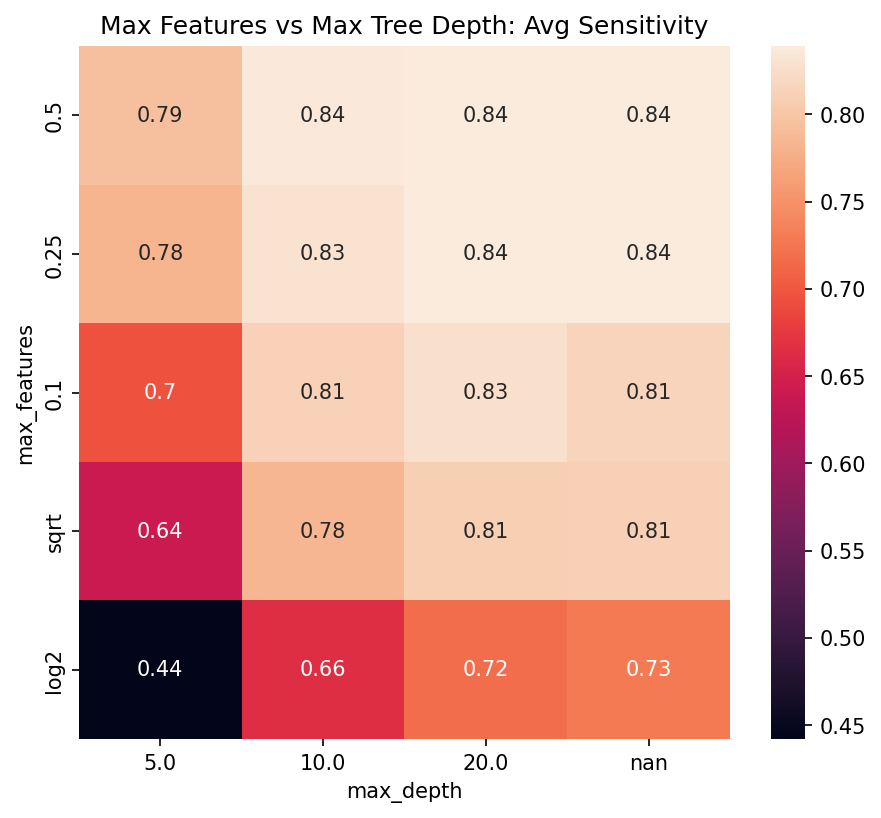

In [56]:
import seaborn as sns
# results_df['max_depth'] = results_df['max_depth'].astype(str)
# results_df['max_depth'] = pd.Categorical(results_df['max_depth'],['5.0','10.0','20.0','nan'],ordered=True)
# results_df['max_features'] = results_df['max_features'].astype(str)
# print(results_df['max_features'].unique())
# results_df['max_features'] = pd.Categorical(results_df['max_features'],["log2", "sqrt", '0.1', '0.25', '0.5'],ordered=True)
# df_pivoted = results_df.pivot_table(index='max_features', columns='max_depth', values='avg_f1')
results_copy = results_df.copy()
results_copy['max_depth'] = pd.Categorical(
    results_copy['max_depth'],
    categories=['5.0', '10.0', '20.0', 'nan'],
    ordered=True
)

results_copy['max_features'] = pd.Categorical(
    results_copy['max_features'],
    categories=['log2', 'sqrt', '0.1', '0.25', '0.5'][::-1],
    ordered=True
)
df_pivoted = results_copy.pivot_table(
    index='max_features',
    columns='max_depth',
    values='avg_sens',
    aggfunc='max'
)

print(df_pivoted)
fig,ax = plt.subplots(figsize=(7,6),dpi=150)
ax = sns.heatmap(df_pivoted,annot=True,ax=ax)
ax.set_title('Max Features vs Max Tree Depth: Avg Sensitivity')

# ax.set_xticklabels(['5', '10', '20', 'None'])
# ax.set_yticklabels(['log2', 'sqrt', '0.1', '0.25', '0.5'][::-1])

In [57]:
best_result = random_forest_classifier(
        adata.copy(),
        n_estimators=100,
        max_depth=None,
        max_features=0.25,
        min_samples_split=5,
        min_samples_leaf=2,
        bootstrap=True,
        label='best',
        random_state=0
    )

0.8562000928665104
[[0.96837945 0.         0.         0.         0.         0.03162055
  0.        ]
 [0.         0.96774194 0.01612903 0.01612903 0.         0.
  0.        ]
 [0.00436681 0.         0.87336245 0.00873362 0.05240175 0.06113537
  0.        ]
 [0.         0.         0.01746725 0.98253275 0.         0.
  0.        ]
 [0.         0.         0.15436242 0.         0.76510067 0.08053691
  0.        ]
 [0.05696203 0.         0.17721519 0.         0.15822785 0.60759494
  0.        ]
 [0.         0.         0.03703704 0.18518519 0.         0.07407407
  0.7037037 ]]


Text(0.5, 0.98, 'Normalized Confusion Matrix')

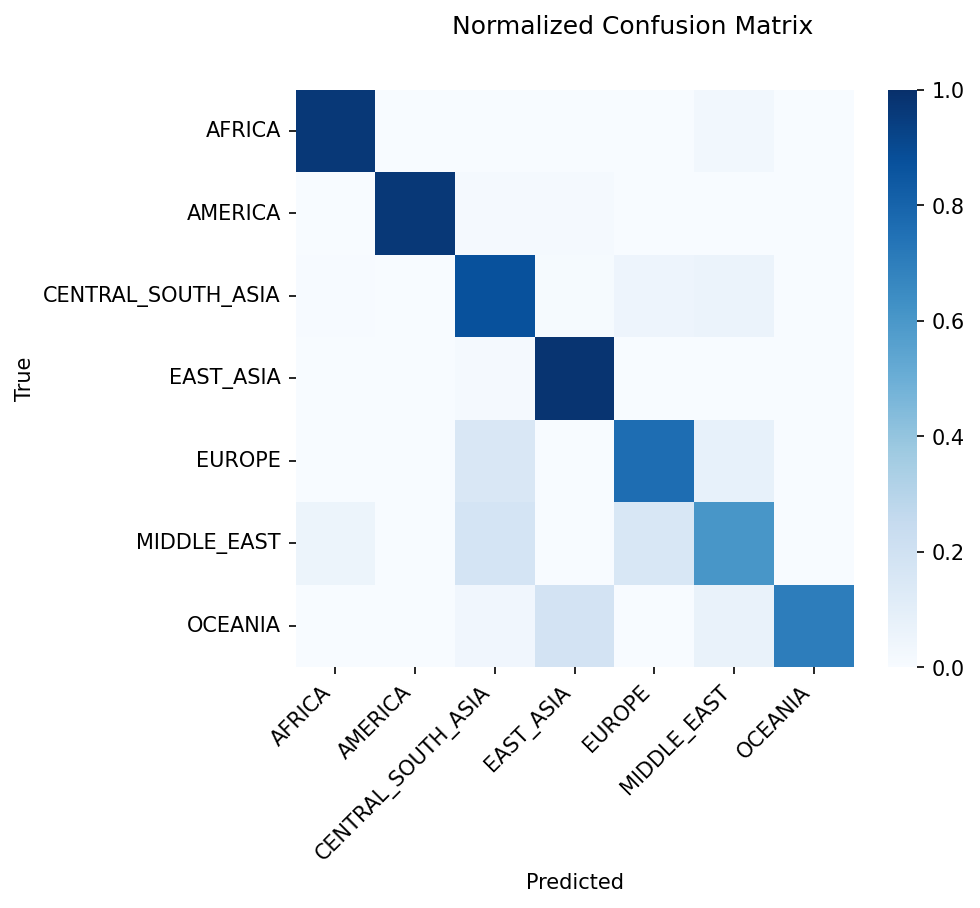

In [62]:
from sklearn.metrics import confusion_matrix
region_order = best_result.obs[['geo_region_of_origin','class_id']].drop_duplicates().sort_values(by='class_id').reset_index(drop=True)['geo_region_of_origin'].tolist()
y_true = best_result.obs['class_id'].to_numpy()
y_pred = best_result.obs['pred'].to_numpy()

print(f1_score(y_true,y_pred,average='macro'))
cm = confusion_matrix(y_true, y_pred)

cm_norm = cm / cm.sum(axis=1, keepdims=True)
print(cm_norm)

import matplotlib.pyplot as plt
fig,ax = plt.subplots(figsize=(6,5),dpi=150)
sns.heatmap(cm_norm, cmap='Blues',ax=ax,vmin=0,vmax=1)
ax.set_xlabel("Predicted")
ax.set_xticklabels(region_order,rotation=45,ha='right')
ax.set_ylabel("True")
ax.set_yticklabels(region_order,ha='right',rotation=0)
# ax.set_xticks(ax.get_xticks()
fig.suptitle("Normalized Confusion Matrix")